# EDA quickstart — papers_combined.parquet

**Start here if this is your first time in the repo.** `data/processed/papers_combined.parquet`
is the single, cleaned, model-ready dataset for this project: one row per paper,
pooling all 6 use cases together. It's built by
`notebooks/main/01_data_compile.ipynb` from the raw JSONL exports +
`usecase.json` search-brief files in `data/raw/` — see that notebook if you want to
know exactly how a column was produced.

A few columns worth knowing before you start:

- **`paper_id`** — the unique key for a row. Use this, not `source_id` (the original
  per-file id), which repeats across use cases.
- **`use_case_key`** / **`use_case_name`** — which of the 6 use cases a row belongs to.
- **`triage_label`** — the analyst's positive/negative/pass judgement. A **null** here
  means "never triaged" — a different fact from `'pass'`, not the same thing.
- **`embedding`** — the precomputed 384-dimension sentence vector for the paper's
  title+abstract, ready to use as model features.
- Everything else is either paper metadata (title, abstract, year, venue, citation
  count, ...) or the matching use case's search-brief fields (`objective`,
  `terms_must_include`, `trl_min`/`trl_max`, ...) broadcast onto every row.

Beyond the basic shape/dtype/missingness check in section 1, **this notebook builds a
set of presentation-ready slides** — one chart or table per question, each exported to
`reports/eda_quickstart_<name>.{png,csv}` so they can be dropped straight into slides.
Every section below ends with 1-3 printed takeaways — the numbers a slide's bullet
points would state. Use case names are relabelled here (`USE_CASE_DISPLAY` below) to
cleaner, slide-friendly titles — display only, the underlying data's `use_case_key`/
`use_case_name` are untouched.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_PATH = Path("../../data/processed/papers_combined.parquet")
REPORTS_DIR = Path("../../reports")

# Same palette as wf_data_enrich.ipynb / explore_use_cases.ipynb /
# explore_usecase_definitions.ipynb / scripts/latent_space_utils.py, so the label/use-case
# color language stays identical across every EDA notebook and script in the repo.
LABEL_COLORS = {"positive": "#2ca02c", "negative": "#d62728", "pass": "#9467bd"}
UNLABELLED_COLOR = "#c7c7c7"
USE_CASE_COLORS = ["#2a78d6", "#1baf7a", "#eda100", "#4a3aa7", "#e87ba4", "#eb6834"]

# Cleaner, slide-friendly titles for this notebook only — the source data's own
# use_case_name (broadcast from each usecase.json's "name" field) is untouched.
USE_CASE_DISPLAY = {
    "carbon_capture": "Carbon Capture",
    "cement_binders": "Low-Carbon Cement",
    "solar_leo": "Solar Cells for Satellites",
    "soil_microbiome": "Soil Microbiome",
    "ner": "Named Entity Recognition",
    "tech_forecasting": "Technology Prediction",
}

# Slide-friendly display names for triage_label, matching how a reviewer actually
# talks about a paper rather than the raw enum value.
LABEL_DISPLAY = {"positive": "Interesting", "negative": "Not interesting", "pass": "Pass"}
NEVER_TRIAGED = "Never triaged"

# Cleaner, non-technical feature names for slide axes/ticks/titles — no underscores,
# consistent everywhere a feature is named across this notebook's charts and tables.
FEATURE_DISPLAY = {
    "title": "Title",
    "abstract_present": "Abstract",
    "authors": "Authors",
    "year": "Year",
    "venue": "Venue",
    "doi": "DOI",
    "citation_count": "Citations",
    "citation_count_log1p": "Citations",
    "paper_age": "Paper Age",
    "n_authors": "Number of Authors",
    "n_papers": "Papers",
}

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "text.color": "#0b0b0b",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "font.size": 10,
})


def export_fig(fig, name):
    path = REPORTS_DIR / f"eda_quickstart_{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  saved {path}")


def export_table(table, name):
    path = REPORTS_DIR / f"eda_quickstart_{name}.csv"
    table.to_csv(path)
    print(f"  saved {path}")


df = pd.read_parquet(DATA_PATH)
USE_CASE_ORDER = sorted(df["use_case_key"].unique())
USE_CASE_COLOR_MAP = dict(zip(USE_CASE_ORDER, USE_CASE_COLORS))
LABEL_ORDER = ["positive", "negative", "pass"]  # NaN ("never triaged") handled separately

assert set(USE_CASE_DISPLAY) == set(USE_CASE_ORDER), "USE_CASE_DISPLAY is missing/has extra use case keys"

print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns from {DATA_PATH}")

Loaded 2873 rows, 50 columns from ../../data/processed/papers_combined.parquet


## 1. Shape and columns

The basics: how big is this, and what's in it. (Onboarding reference, not a slide.)

In [2]:
df.head()

,paper_id,use_case_key,use_case_name,source_id,title,authors,year,venue,doi,url,...,notes,from_arxiv,from_core,from_crossref,from_europe_pmc,from_openalex,from_pubmed,from_seed,from_semantic_scholar,has_abstract
0,carbon_capture__3355,carbon_capture,Carbon Capture,3355,Optimization of amine-based carbon capture: Si...,"Amin Hedayati Moghaddam, Morteza Esfandyari, H...",2024,results in engineering,10.1016/j.rineng.2024.103574,https://doi.org/10.1016/j.rineng.2024.103574,...,,False,False,True,False,False,False,False,False,True
1,carbon_capture__1143,carbon_capture,Carbon Capture,1143,Solvent-mediated modification of thermodynamic...,"N. D. Afify, M. B. Sweatman",2024,the journal of chemical physics,10.1063/5.0169382,https://doi.org/10.1063/5.0169382,...,,False,False,True,False,False,False,False,False,True
2,carbon_capture__1588,carbon_capture,Carbon Capture,1588,Electrifying amine carbon capture with robust ...,"Li X, Musgrave CB, Liu A, Meng J, Zhang J, God...",2025,,10.1038/s41467-025-59732-z,https://doi.org/10.1038/s41467-025-59732-z,...,,False,False,False,True,False,False,False,False,True
3,carbon_capture__1621,carbon_capture,Carbon Capture,1621,Impact of thermodynamics and kinetics on the c...,"Kopac T, Demirel Y.",2024,,10.1007/s11356-024-33792-y,https://doi.org/10.1007/s11356-024-33792-y,...,,False,False,False,True,False,False,False,False,True
4,carbon_capture__3493,carbon_capture,Carbon Capture,3493,Acid-treated activated carbon as simple and in...,"Ali Hassan Bhatti, Mamoona Waris, Wajahat Wahe...",2023,carbon capture science & technology,10.1016/j.ccst.2023.100131,https://ars.els-cdn.com/content/image/1-s2.0-S...,...,,False,False,False,False,True,False,False,False,True


In [3]:
df.dtypes

paper_id                        str
use_case_key                    str
use_case_name                   str
source_id                     int64
title                           str
authors                         str
year                          Int64
venue                           str
doi                             str
url                             str
sources                         str
language                        str
citation_count                Int64
triage_label               category
review_label               category
relevance_score             float64
abstract                        str
embedding                    object
embed_model                     str
embed_dim                     int64
exported_at                     str
app_version                     str
problem_statement               str
objective                       str
usecase_schema_version          str
domain_industry                 str
domain_application              str
domain_technology_focus     

## 2. Slide — the total dataset by label

How much of the corpus has actually been triaged, and how did it come down: interesting,
not interesting, or pass?

  saved ../../reports/eda_quickstart_1_total_by_label.png
  saved ../../reports/eda_quickstart_1_total_by_label.csv


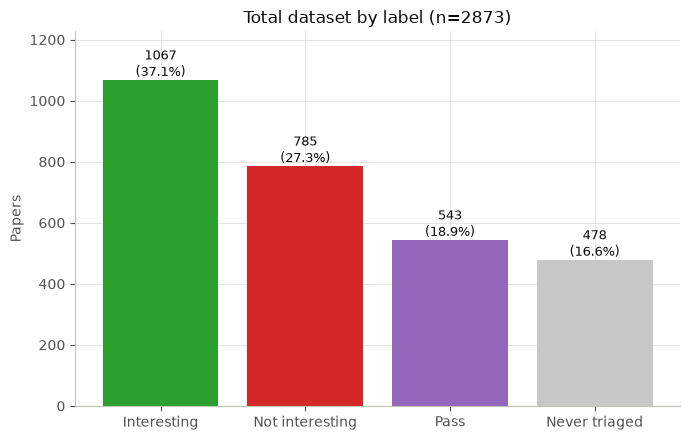

Takeaways:
- 2395/2873 papers (83.4%) have been triaged at all; 478 (16.6%) are still in the backlog.
- Of triaged papers, 1852/2395 (77.3%) got a firm interesting/not-interesting call; the rest (543, 22.7%) were passed.
- Among firm decisions, interesting:not-interesting runs 1067:785 (57.6% positive) — a mild, not extreme, class imbalance.


In [4]:
label_counts = df["triage_label"].value_counts(dropna=False).reindex(LABEL_ORDER + [np.nan])
label_counts.index = [LABEL_DISPLAY[l] if pd.notna(l) else NEVER_TRIAGED for l in label_counts.index]
label_pct = (label_counts / label_counts.sum() * 100).round(1)

colors = [LABEL_COLORS.get(k, UNLABELLED_COLOR) for k in LABEL_ORDER] + [UNLABELLED_COLOR]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(label_counts.index, label_counts.values, color=colors)
for bar, count, pct in zip(bars, label_counts.values, label_pct.values):
    ax.annotate(f"{count}\n({pct}%)", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=9)
ax.set_ylabel(FEATURE_DISPLAY["n_papers"])
ax.set_title(f"Total dataset by label (n={len(df)})")
ax.margins(y=0.15)
plt.tight_layout()
export_fig(fig, "1_total_by_label")
export_table(label_counts.rename(FEATURE_DISPLAY["n_papers"]).to_frame().assign(pct=label_pct), "1_total_by_label")
plt.show()

triaged = df["triage_label"].notna().sum()
n_pos, n_neg, n_pass = (df["triage_label"] == "positive").sum(), (df["triage_label"] == "negative").sum(), (df["triage_label"] == "pass").sum()
n_decided = n_pos + n_neg
print("Takeaways:")
print(f"- {triaged}/{len(df)} papers ({triaged / len(df):.1%}) have been triaged at all; "
      f"{len(df) - triaged} ({(len(df) - triaged) / len(df):.1%}) are still in the backlog.")
print(f"- Of triaged papers, {n_decided}/{triaged} ({n_decided / triaged:.1%}) got a firm "
      f"interesting/not-interesting call; the rest ({n_pass}, {n_pass / triaged:.1%}) were passed.")
print(f"- Among firm decisions, interesting:not-interesting runs {n_pos}:{n_neg} "
      f"({n_pos / n_decided:.1%} positive) — a mild, not extreme, class imbalance.")

## 3. Slide — each use case, with its brief, by label

Same label breakdown, but split per use case — alongside the one-line objective from
that use case's search brief, for slide context.

  saved ../../reports/eda_quickstart_2_use_cases_by_label.png
  saved ../../reports/eda_quickstart_2_use_cases_by_label.csv


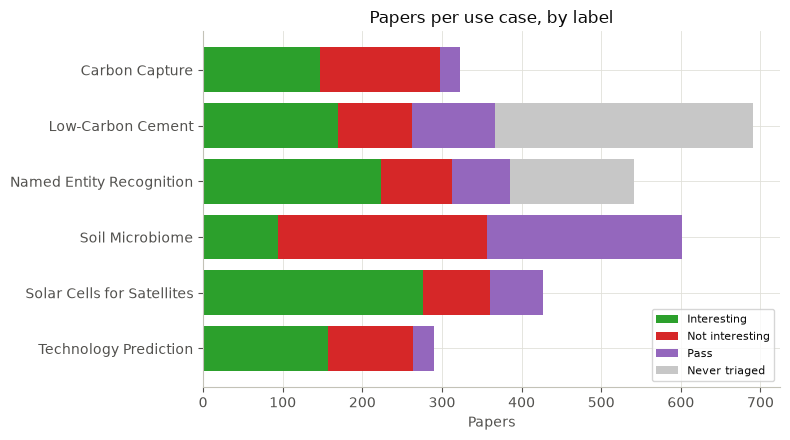

Takeaways:
- "Solar Cells for Satellites" has the highest hit rate among firm decisions: 76.7% positive.
- "Low-Carbon Cement" has the largest untriaged backlog: 46.8% of its papers never reviewed.
- Use case sizes range 290-690 papers — comparisons across use cases should read percentages, not raw counts.


In [5]:
brief = df.groupby("use_case_key", observed=True)["objective"].first()

rows = []
for uc in USE_CASE_ORDER:
    sub = df.loc[df["use_case_key"] == uc, "triage_label"]
    row = {"use_case_key": uc, "use_case_label": USE_CASE_DISPLAY[uc], "objective": brief[uc], "n_papers": len(sub)}
    for lab in LABEL_ORDER:
        row[lab] = int((sub == lab).sum())
    row["never_triaged"] = int(sub.isna().sum())
    rows.append(row)
use_case_labels = pd.DataFrame(rows).set_index("use_case_key")

fig, ax = plt.subplots(figsize=(8, 4.5))
left = np.zeros(len(use_case_labels))
for lab, color in [("positive", LABEL_COLORS["positive"]), ("negative", LABEL_COLORS["negative"]),
                    ("pass", LABEL_COLORS["pass"]), ("never_triaged", UNLABELLED_COLOR)]:
    values = use_case_labels[lab].values
    ax.barh(use_case_labels["use_case_label"], values, left=left, color=color,
            label=LABEL_DISPLAY.get(lab, NEVER_TRIAGED))
    left += values
ax.set_xlabel(FEATURE_DISPLAY["n_papers"])
ax.set_title("Papers per use case, by label")
ax.legend(fontsize=8, loc="lower right")
ax.invert_yaxis()
plt.tight_layout()
export_fig(fig, "2_use_cases_by_label")
export_table(use_case_labels, "2_use_cases_by_label")
plt.show()

use_case_labels["positive_rate_of_decided"] = use_case_labels["positive"] / (use_case_labels["positive"] + use_case_labels["negative"])
use_case_labels["never_triaged_rate"] = use_case_labels["never_triaged"] / use_case_labels["n_papers"]
top_positive = use_case_labels["positive_rate_of_decided"].idxmax()
top_backlog = use_case_labels["never_triaged_rate"].idxmax()
print("Takeaways:")
print(f"- \"{use_case_labels.loc[top_positive, 'use_case_label']}\" has the highest hit rate among firm decisions: "
      f"{use_case_labels.loc[top_positive, 'positive_rate_of_decided']:.1%} positive.")
print(f"- \"{use_case_labels.loc[top_backlog, 'use_case_label']}\" has the largest untriaged backlog: "
      f"{use_case_labels.loc[top_backlog, 'never_triaged_rate']:.1%} of its papers never reviewed.")
print(f"- Use case sizes range {use_case_labels['n_papers'].min()}-{use_case_labels['n_papers'].max()} "
      f"papers — comparisons across use cases should read percentages, not raw counts.")

## 4. Slide — missingness, across the features that matter

`NULL != 0` is a non-negotiable convention in this project: "never found out" and
"found nothing" are different facts, so nothing here gets `fillna(0)`'d away. One trap
worth flagging up front: a missing **abstract** is stored as an **empty string**, not
`NaN` — `abstract.isna()` reports zero missing regardless of label; the real signal is
the `has_abstract` boolean.

  saved ../../reports/eda_quickstart_3_missingness.png
  saved ../../reports/eda_quickstart_3_missingness.csv


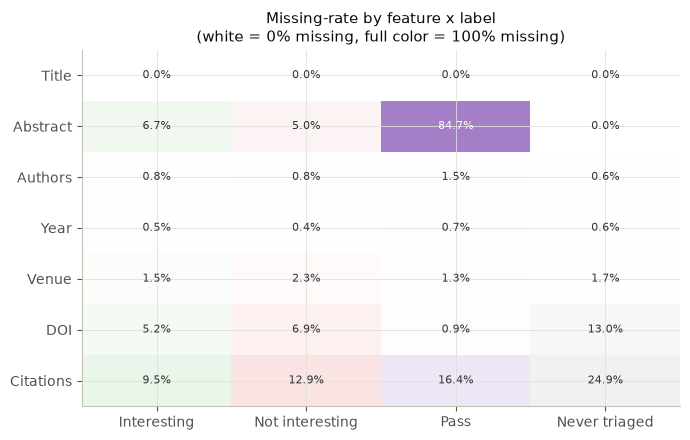

Takeaways:
- 84.7% of 'Pass' papers have no abstract at all — pass decisions look like mostly title-only quick-rejects, not full reads.
- Never-triaged papers have the highest Citations gap (24.9% missing) of any group — the backlog skews toward less-enriched records.
- TRL range is an all-or-nothing feature by use case (6/6 use cases are 0% or 100% missing) — that's a property of whether the use case's brief specified a TRL range at all, not random data loss.


In [6]:
FEATURES = ["title", "abstract_present", "authors", "year", "venue", "doi", "citation_count"]
df["abstract_present"] = df["has_abstract"]

label_groups = df["triage_label"].astype("object").fillna(NEVER_TRIAGED).replace(LABEL_DISPLAY)
group_order = [LABEL_DISPLAY["positive"], LABEL_DISPLAY["negative"], LABEL_DISPLAY["pass"], NEVER_TRIAGED]
group_base_color = {LABEL_DISPLAY["positive"]: LABEL_COLORS["positive"], LABEL_DISPLAY["negative"]: LABEL_COLORS["negative"],
                     LABEL_DISPLAY["pass"]: LABEL_COLORS["pass"], NEVER_TRIAGED: UNLABELLED_COLOR}

missing_rate = pd.DataFrame(index=FEATURES, columns=group_order, dtype=float)
for feat in FEATURES:
    if feat == "abstract_present":
        missing = ~df[feat]
    else:
        missing = df[feat].isna()
    missing_rate.loc[feat] = missing.groupby(label_groups).mean().reindex(group_order)
missing_rate.index = [FEATURE_DISPLAY[f] for f in FEATURES]

# Each column is shaded in its OWN label color (white = 0% missing -> full color = 100%
# missing), so the missingness chart reads with the same color language as every other
# slide in this notebook, instead of an unrelated generic sequential colormap.
import matplotlib.colors as mcolors

white = np.array([1.0, 1.0, 1.0])
rgb_grid = np.zeros((len(missing_rate.index), len(group_order), 3))
for j, lab in enumerate(group_order):
    base = np.array(mcolors.to_rgb(group_base_color[lab]))
    for i in range(len(missing_rate.index)):
        t = missing_rate.values[i, j]
        rgb_grid[i, j] = white + (base - white) * t

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.imshow(rgb_grid, aspect="auto")
ax.set_xticks(range(len(group_order)))
ax.set_xticklabels(group_order)
ax.set_yticks(range(len(missing_rate.index)))
ax.set_yticklabels(missing_rate.index)
for i in range(missing_rate.shape[0]):
    for j in range(missing_rate.shape[1]):
        val = missing_rate.values[i, j]
        luminance = 0.2126 * rgb_grid[i, j, 0] + 0.7152 * rgb_grid[i, j, 1] + 0.0722 * rgb_grid[i, j, 2]
        ax.text(j, i, f"{val:.1%}", ha="center", va="center",
                color="white" if luminance < 0.6 else "#333333", fontsize=8)
ax.set_title("Missing-rate by feature x label\n(white = 0% missing, full color = 100% missing)", fontsize=11)
plt.tight_layout()
export_fig(fig, "3_missingness")
export_table(missing_rate, "3_missingness")
plt.show()

pass_abstract_missing = missing_rate.loc[FEATURE_DISPLAY["abstract_present"], LABEL_DISPLAY["pass"]]
never_triaged_citation_missing = missing_rate.loc[FEATURE_DISPLAY["citation_count"], NEVER_TRIAGED]
trl_missing_by_uc = df.groupby("use_case_key")["trl_min"].apply(lambda s: s.isna().mean())
all_or_nothing_uc = trl_missing_by_uc[(trl_missing_by_uc == 0) | (trl_missing_by_uc == 1)]
print("Takeaways:")
print(f"- {pass_abstract_missing:.1%} of 'Pass' papers have no abstract at all — pass decisions "
      f"look like mostly title-only quick-rejects, not full reads.")
print(f"- Never-triaged papers have the highest {FEATURE_DISPLAY['citation_count']} gap "
      f"({never_triaged_citation_missing:.1%} missing) of any group — the backlog skews toward "
      f"less-enriched records.")
print(f"- TRL range is an all-or-nothing feature by use case ({len(all_or_nothing_uc)}/{len(trl_missing_by_uc)} "
      f"use cases are 0% or 100% missing) — that's a property of whether the use case's brief specified a "
      f"TRL range at all, not random data loss.")

## 5. Slide — data skew: citations, age, and authors by use case

`citation_count` is heavily right-skewed (a handful of highly-cited papers dominate the
mean), so it's shown log-scaled. `paper_age` and `n_authors` are derived here the same
way as `notebooks/main/04_feature_engineering.ipynb` derives them (age from
the export timestamp, not a hardcoded "current year"; authors from a comma-split of the
`authors` field) — kept in sync so this slide and the FE dataset never quietly disagree.

  saved ../../reports/eda_quickstart_4_skew_by_use_case.png


  saved ../../reports/eda_quickstart_4_skew_by_use_case.csv


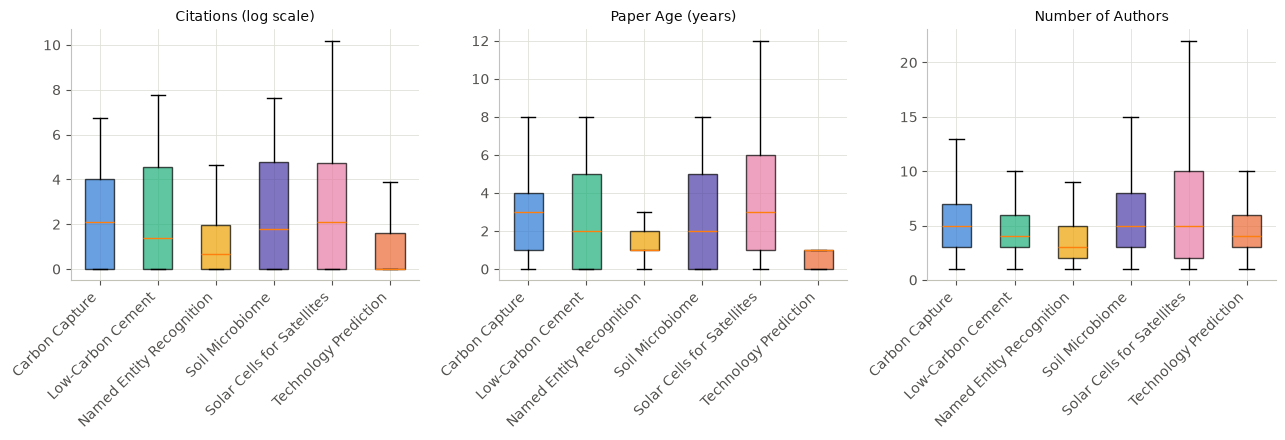

Takeaways:
- Oldest median paper age (3 years): Carbon Capture, Solar Cells for Satellites; Citations spread is widest in "Solar Cells for Satellites" (a few outlier hits skew the mean well above the median there).
- Largest median author-team size (5): Carbon Capture, Soil Microbiome, Solar Cells for Satellites — worth knowing if author-count ever becomes a feature.
- Boxplots hide outliers by design (showfliers=False) — the full-precision numbers are in the exported CSV, not just the chart.


In [7]:
exported_year = pd.to_datetime(df["exported_at"]).dt.year
df["paper_age"] = (exported_year - df["year"]).clip(lower=0)


def count_authors(value):
    if pd.isna(value) or str(value).strip() == "":
        return np.nan
    return float(len(str(value).split(",")))


df["n_authors"] = df["authors"].map(count_authors)
df["citation_count_log1p"] = np.log1p(df["citation_count"])

metrics = [
    ("citation_count_log1p", f"{FEATURE_DISPLAY['citation_count_log1p']} (log scale)"),
    ("paper_age", f"{FEATURE_DISPLAY['paper_age']} (years)"),
    ("n_authors", FEATURE_DISPLAY["n_authors"]),
]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, (col, label) in zip(axes, metrics):
    data = [df.loc[df["use_case_key"] == uc, col].dropna().values for uc in USE_CASE_ORDER]
    bp = ax.boxplot(data, patch_artist=True, showfliers=False)
    for patch, uc in zip(bp["boxes"], USE_CASE_ORDER):
        patch.set_facecolor(USE_CASE_COLOR_MAP[uc])
        patch.set_alpha(0.7)
    ax.set_xticks(range(1, len(USE_CASE_ORDER) + 1))
    ax.set_xticklabels([USE_CASE_DISPLAY[uc] for uc in USE_CASE_ORDER], rotation=45, ha="right")
    ax.set_title(label, fontsize=10)
plt.tight_layout()
export_fig(fig, "4_skew_by_use_case")

skew_summary = df.groupby("use_case_key")[["citation_count", "paper_age", "n_authors"]].agg(["median", "mean", "std"])
skew_summary.columns = pd.MultiIndex.from_tuples([(FEATURE_DISPLAY[a], b) for a, b in skew_summary.columns])
skew_summary.index = [USE_CASE_DISPLAY[uc] for uc in skew_summary.index]
export_table(skew_summary, "4_skew_by_use_case")
plt.show()

age_medians = df.groupby("use_case_key")["paper_age"].median()
oldest_ucs = age_medians[age_medians == age_medians.max()].index.tolist()
most_cited_var_uc = df.groupby("use_case_key")["citation_count"].std().idxmax()
author_medians = df.groupby("use_case_key")["n_authors"].median()
most_authors_ucs = author_medians[author_medians == author_medians.max()].index.tolist()
print("Takeaways:")
print(f"- Oldest median paper age ({age_medians.max():.0f} years): "
      f"{', '.join(USE_CASE_DISPLAY[u] for u in oldest_ucs)}; "
      f"{FEATURE_DISPLAY['citation_count']} spread is widest in \"{USE_CASE_DISPLAY[most_cited_var_uc]}\" (a few outlier "
      f"hits skew the mean well above the median there).")
print(f"- Largest median author-team size ({author_medians.max():.0f}): "
      f"{', '.join(USE_CASE_DISPLAY[u] for u in most_authors_ucs)} "
      f"— worth knowing if author-count ever becomes a feature.")
print(f"- Boxplots hide outliers by design (showfliers=False) — the full-precision numbers are "
      f"in the exported CSV, not just the chart.")

## 6. Slide — embeddings exploration

The corpus's precomputed 384-dim embedding (`paraphrase-multilingual-MiniLM-L12-v2`,
the same vectors `academic_research_agent`'s own UI ranked by), projected to 2D with
PCA — the same projection method already used in `scripts/latent_space_utils.py`
(no new dependency: no UMAP/t-SNE library is installed in this repo). Two readings of
the same map: colored by use case, then by label.

  saved ../../reports/eda_quickstart_5_embeddings_pca.png


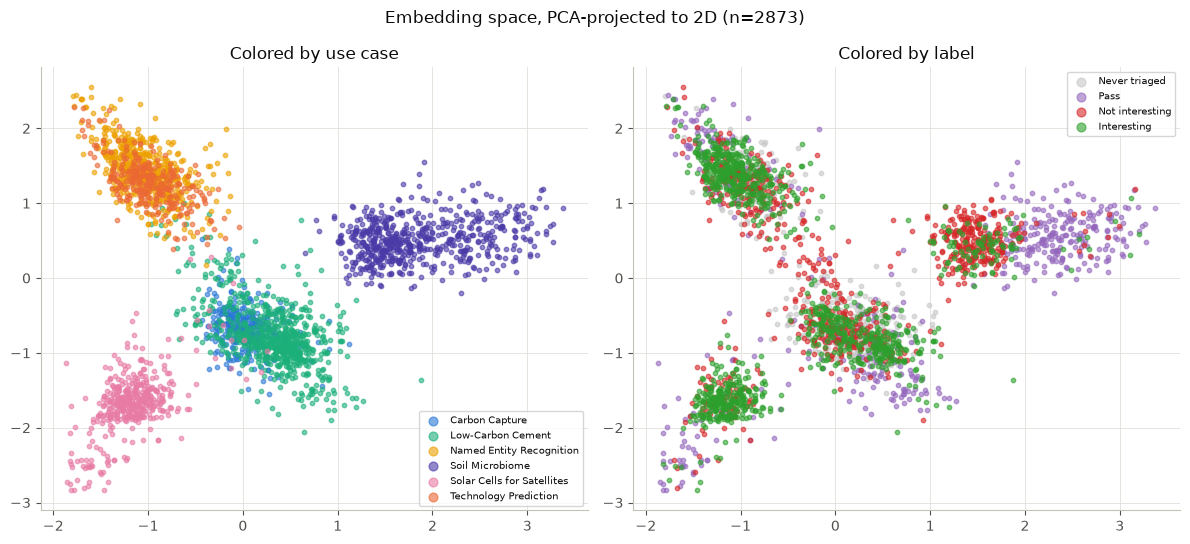

In [8]:
from sklearn.decomposition import PCA

V = np.vstack(df["embedding"].to_numpy())
coords = PCA(n_components=2, random_state=42).fit_transform(V)
df["_pca_x"], df["_pca_y"] = coords[:, 0], coords[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

ax = axes[0]
for uc in USE_CASE_ORDER:
    mask = df["use_case_key"] == uc
    ax.scatter(df.loc[mask, "_pca_x"], df.loc[mask, "_pca_y"], s=10, alpha=0.6,
               color=USE_CASE_COLOR_MAP[uc], label=USE_CASE_DISPLAY[uc])
ax.set_title("Colored by use case")
ax.legend(fontsize=7, loc="best", markerscale=2)

ax = axes[1]
draw_order = [(None, UNLABELLED_COLOR, NEVER_TRIAGED), ("pass", LABEL_COLORS["pass"], "Pass"),
              ("negative", LABEL_COLORS["negative"], "Not interesting"),
              ("positive", LABEL_COLORS["positive"], "Interesting")]
for lab, color, legend_label in draw_order:
    mask = df["triage_label"].isna() if lab is None else (df["triage_label"] == lab)
    ax.scatter(df.loc[mask, "_pca_x"], df.loc[mask, "_pca_y"], s=10, alpha=0.6, color=color, label=legend_label)
ax.set_title("Colored by label")
ax.legend(fontsize=7, loc="best", markerscale=2)

fig.suptitle("Embedding space, PCA-projected to 2D (n=%d)" % len(df))
plt.tight_layout()
export_fig(fig, "5_embeddings_pca")
plt.show()

In [9]:
def pairwise_cosine_mean(V_subset):
    if len(V_subset) < 2:
        return np.nan
    norm = V_subset / np.linalg.norm(V_subset, axis=1, keepdims=True)
    sims = norm @ norm.T
    iu = np.triu_indices_from(sims, k=1)
    return float(sims[iu].mean())


within_use_case = {USE_CASE_DISPLAY[uc]: pairwise_cosine_mean(V[(df["use_case_key"] == uc).to_numpy()]) for uc in USE_CASE_ORDER}
corpus_wide = pairwise_cosine_mean(V)
dispersion_table = pd.Series(within_use_case, name="avg_pairwise_cosine_within_use_case").to_frame()
dispersion_table.loc["ALL (corpus-wide)"] = corpus_wide
export_table(dispersion_table, "5_embeddings_dispersion")
print(dispersion_table.round(3))

print()
print("Takeaways:")
print(f"- Papers cluster tightly by use case: avg within-use-case pairwise cosine similarity "
      f"({pd.Series(within_use_case).mean():.2f} avg) is well above the corpus-wide figure "
      f"({corpus_wide:.2f}) — the embedding space mostly encodes topic/domain, visible as the "
      f"clean clusters in the left panel.")
print(f"- Interesting vs. not-interesting overlap heavily within a use case (right panel) — "
      f"there's no clean visual boundary. This matches both this project's earlier embedding "
      f"bake-off (ROC-AUC ~0.77-0.80, well short of separable) and a colleague's own PCA sanity "
      f"check in sf_eda_v2.ipynb — independent confirmation embeddings alone aren't a clean "
      f"classifier, motivating the lexical-feature work in scripts/lexical_features.py.")
print(f"- This is one embedding model (the export's default). "
      f"notebooks/main/04_feature_engineering.ipynb and reports/wf_embedding_bakeoff.md "
      f"compare it against several stronger candidates on labelled rows only.")

  saved ../../reports/eda_quickstart_5_embeddings_dispersion.csv
                            avg_pairwise_cosine_within_use_case
Carbon Capture                                            0.589
Low-Carbon Cement                                         0.435
Named Entity Recognition                                  0.404
Soil Microbiome                                           0.557
Solar Cells for Satellites                                0.712
Technology Prediction                                     0.496
ALL (corpus-wide)                                         0.193

Takeaways:
- Papers cluster tightly by use case: avg within-use-case pairwise cosine similarity (0.53 avg) is well above the corpus-wide figure (0.19) — the embedding space mostly encodes topic/domain, visible as the clean clusters in the left panel.
- Interesting vs. not-interesting overlap heavily within a use case (right panel) — there's no clean visual boundary. This matches both this project's earlier embedding ba

## Exported files

Everything a slide could need, written by the sections above.

In [10]:
exported = sorted(REPORTS_DIR.glob("eda_quickstart_*"))
for path in exported:
    print(f"{path.name:45s} {path.stat().st_size / 1024:>8.1f} KB")

eda_quickstart_1_total_by_label.csv                0.1 KB
eda_quickstart_1_total_by_label.png               36.5 KB
eda_quickstart_2_use_cases_by_label.csv            1.5 KB
eda_quickstart_2_use_cases_by_label.png           44.4 KB
eda_quickstart_3_missingness.csv                   0.6 KB
eda_quickstart_3_missingness.png                  63.7 KB
eda_quickstart_4_skew_by_use_case.csv              1.0 KB
eda_quickstart_4_skew_by_use_case.png             99.5 KB
eda_quickstart_5_embeddings_dispersion.csv         0.3 KB
eda_quickstart_5_embeddings_pca.png              411.9 KB


## Where to go next

- **`explore_use_cases.ipynb`** — deeper structure/volume comparison across the 6
  raw JSONL exports (schema, null rates, label balance, duplicates).
- **`explore_usecase_definitions.ipynb`** — structure of the 6 `usecase.json` search
  briefs, and how each definition compares against its resulting corpus.
- **`01_data_compile.ipynb`** — exactly how `papers_combined.parquet`
  was built, and every cleaning decision made along the way.
- **`04_feature_engineering.ipynb`** — where the lexical + embedding
  features touched on in sections 5-6 get assembled into the actual modelling dataset.
- Root **`README.md`** — this project's non-negotiable conventions (NULL != 0,
  cross-validate honestly, label which critic is speaking) — worth reading before
  you build anything on top of this data.